# Problem set 6

- Below are the functions necessary to complete problem set 4
- We will use an internal data set that is available in r-studio

## A.1 Import receipts data

In [1]:
#Imports internal data set
data(mtcars)

## A.2 Import packages

In [2]:
library(dplyr) #Data manipulation
library(ggplot2) #Plotting
library(lmtest)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Registered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang
Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



# 1. Pre-regression

## 1.1 Plot

- `PS6 corresponding problem: 1.b`


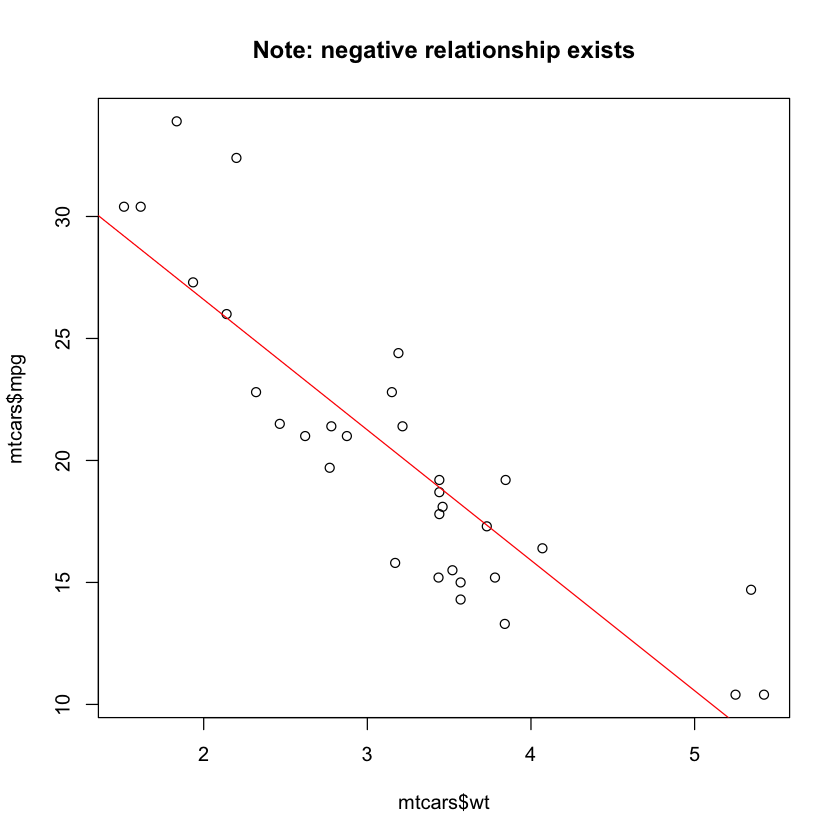

In [3]:
#Scatter
plot(mtcars$wt,mtcars$mpg, main='Note: negative relationship exists')

#linear regression line
abline(lm(mpg~wt, data= mtcars), col="red")
#Common mistake is that abeline order matters The following would not work
# abline(lm(mpg~wt, data= mtcars), col="red")

# 2. Regression

- `PS6 corresponding problem: 1.a`


## 2.1 Basic regression

In [4]:
lm(wt~mpg , data= mtcars)


Call:
lm(formula = wt ~ mpg, data = mtcars)

Coefficients:
(Intercept)          mpg  
     6.0473      -0.1409  


## 2.2 Summary of regression

In [5]:
reg_output = lm(wt~mpg , data= mtcars)

In [6]:
summary(reg_output)


Call:
lm(formula = wt ~ mpg, data = mtcars)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.6516 -0.3490 -0.1381  0.3190  1.3684 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  6.04726    0.30869  19.590  < 2e-16 ***
mpg         -0.14086    0.01474  -9.559 1.29e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4945 on 30 degrees of freedom
Multiple R-squared:  0.7528,	Adjusted R-squared:  0.7446 
F-statistic: 91.38 on 1 and 30 DF,  p-value: 1.294e-10


# 3. Residuals

- `PS6 corresponding problem: 1.e`


## 3.1 Extract from regression output

In [7]:
reg_output = lm(mpg~wt , data= mtcars)
reg_output$residuals[c(1,4)] #Remove [c(1,4)] to show all residuals

Mazda RX4 Hornet 4 Drive 
     -2.282611       1.297350

In [8]:
residuals = reg_output$residuals

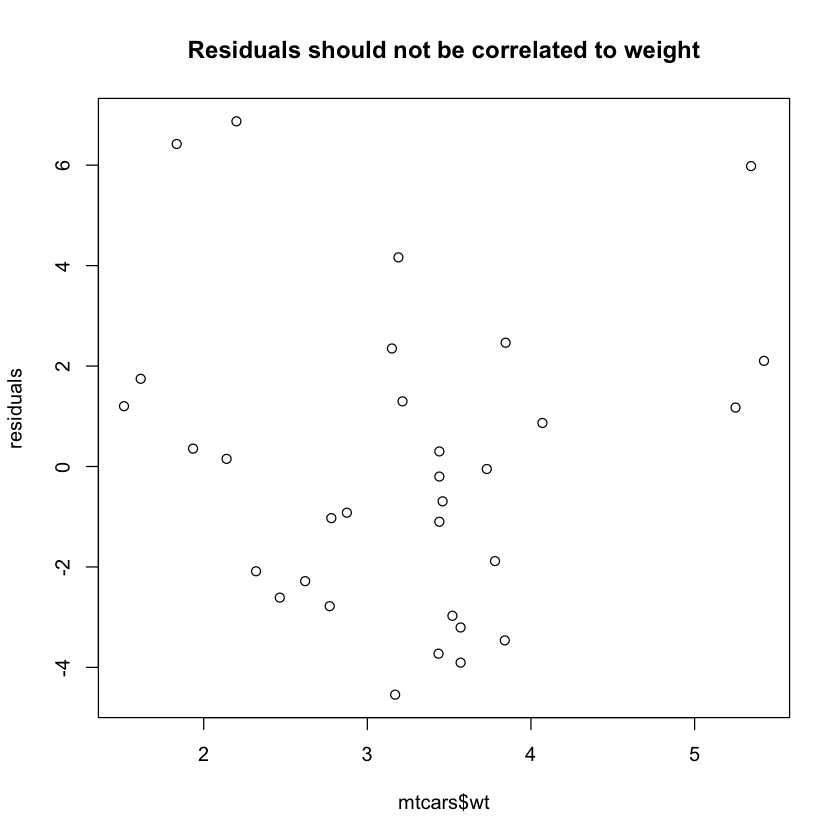

In [9]:
plot(x=mtcars$wt, y=residuals, main='Residuals should not be correlated to weight')

# 4. Single regressions--multiple
- `PS6 corresponding problem: 2`


## 4.1 Non-iterative

### 4.1.1 Extract r2 and residuals

- `PS6 corresponding problem: 2.a`


In [10]:
reg_output = summary(lm(mpg~wt, data= mtcars))
coeffs = reg_output$coefficients[2]
r2 = reg_output$r.squared
table = cbind(coeffs,r2)
rownames(table) = 'Regressor: Weight'
table

,coeffs,r2
Regressor: Weight,-5.344472,0.7528328


### 4.1.1 Graph 4 plots
- `PS6 corresponding problem: 2.b`


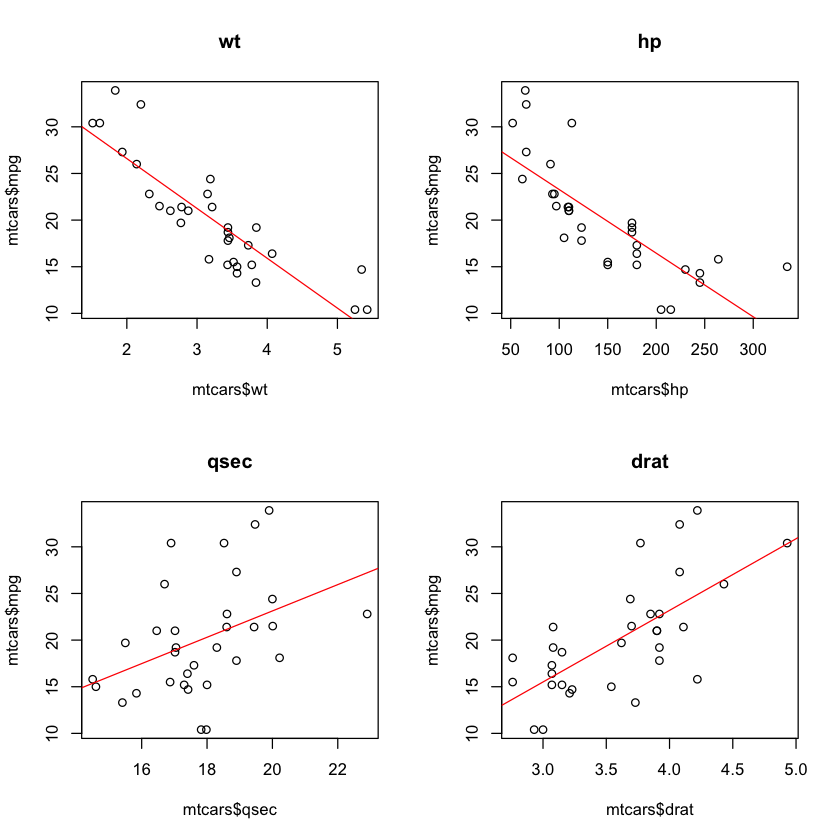

In [11]:
par(mfrow=c(2,2))
plot(mtcars$wt, mtcars$mpg, main='wt')
abline(lm(mpg~wt, data= mtcars), col="red")

plot(mtcars$hp, mtcars$mpg, main='hp')
abline(lm(mpg~hp, data= mtcars), col="red")

plot(mtcars$qsec, mtcars$mpg, main='qsec')
abline(lm(mpg~qsec, data= mtcars), col="red")

plot(mtcars$drat, mtcars$mpg, main='drat')
abline(lm(mpg~drat, data= mtcars), col="red")

## 4.2 Iterate
- This is the same as 4.1.1 but using an iterative loop

- `PS6 corresponding problem: 2.a`

In [12]:
names(mtcars)

[1] "mpg"  "cyl"  "disp" "hp"   "drat" "wt"   "qsec" "vs"   "am"   "gear"
[11] "carb"

In [13]:
regressors = c('hp','wt', 'qsec', 'drat')

In [14]:
for (x in regressors)
{
    eq = paste("mpg ~",x, sep='')
    reg_output = summary(lm(as.formula(eq), data=mtcars))
    coeffs = reg_output$coefficients[2]
    r2 = reg_output$r.squared
    table = cbind(coeffs,r2)
    rownames(table) = x
    print(table)
    #Uncomment the plot to show plots
    #plot(x=mtcars %>% pull(x), y=mtcars %>% pull('mpg'), main=x, xlab=x, ylab='mpg')
    
}

        coeffs        r2
hp -0.06822828 0.6024373
      coeffs        r2
wt -5.344472 0.7528328
       coeffs        r2
qsec 1.412125 0.1752963
       coeffs        r2
drat 7.678233 0.4639952


# 5. Multiple regressions
- `PS6 corresponding problem: 3.c`


- Simply add a plus after each regressor

In [15]:
reg_output = lm(mpg~wt+vs, data= mtcars)
summary(reg_output)


Call:
lm(formula = mpg ~ wt + vs, data = mtcars)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.7071 -2.4415 -0.3129  1.4319  6.0156 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  33.0042     2.3554  14.012 1.92e-14 ***
wt           -4.4428     0.6134  -7.243 5.63e-08 ***
vs            3.1544     1.1907   2.649   0.0129 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.78 on 29 degrees of freedom
Multiple R-squared:  0.801,	Adjusted R-squared:  0.7873 
F-statistic: 58.36 on 2 and 29 DF,  p-value: 6.818e-11


# 6. Interpret regressions